In [16]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, 
                                          models_output_dict)

In [17]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971,
                          scenario = 'SSP2_M_CP',
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)


class_1 = ['class_ 1'] 

high = ['class_ 19', 'class_ 23']

china = ['class_ 20']

low = ['class_ 2', 'class_ 11' , 'class_ 12', 'class_ 13', 'class_ 24']

too_low = ['class_ 4', 'class_ 8', 'class_ 22', 'class_ 25']

very_low = ["class_ 3", "class_ 5", "class_ 6", 
              "class_ 7", "class_ 9", "class_ 17", 
              "class_ 18", "class_ 21", "class_ 26"]

# trajectory not to forseen, will be fitted with global regression
spreaded = ['class_ 10', 'class_ 14', 'class_ 15', 'class_ 16']

exclude = spreaded + too_low


# what is in rest will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (low+class_1+high+very_low+too_low+china)]

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
steel_grouping = {'all' : all_regions_list_class[:-1],
                  'class_ 1': class_1,
                  'high': high,
                  'china': china,
                  'low': low,
                  'very_low': very_low,
                  'too_low': too_low,
               }

#steel_grouping = {'all' : all_regions_list_class[:-1]}
steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()


In [18]:
rest

['class_ 10', 'class_ 14', 'class_ 15', 'class_ 16']

In [19]:
# neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
# steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)

In [20]:
bounds = {
'all': ([0, 0, 0], [10, 10, 10]),
'class_ 1': ([0, 0, 0], [10, 10, 10]),
'high': ([0, 0, 0], [0.7, 10, 10]),
'china': ([0, 0, 0], [0.5, 10, 10]),
'low': ([0, 0, 0], [10, 10, 10]),
'very_low': ([0, 0, 0], [10, 10, 10]),
'too_low': ([0, 0, 0], [10, 10, 10])}

# enforce that for all groups gompertz model is selected as best fit
steel.fit_models(best_rmse_models={'all' : 'gompertz model',
                              'class_ 1': 'gompertz model',
                              'high': 'gompertz model',
                              'china': 'gompertz model',
                              'low': 'gompertz model',
                              'very_low': 'gompertz model',
                              'too_low': 'gompertz model'},
                              bounds=bounds)  


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

In [21]:
# project based on best model
steel.project_on_total(all_regions_list_class[:-1])
steel.smooth_out_interpolation_all(10, 2012)
steel.adjust_alpha_and_project(all_regions_list_class[:-1], 
                            start_year_adjust=2025, 
                            end_year_adjust=2100, 
                            min_alpha=None)

steel.remove_regions_with_no_good_fit_from_region_model_match(exclude)

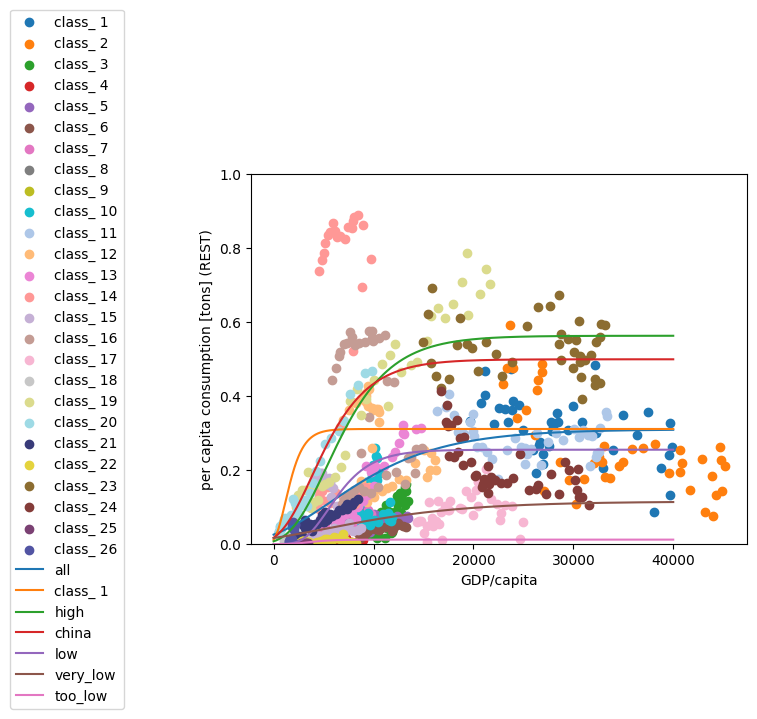

In [22]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

# set ax limits
ax.set_ylim(0, 1)

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


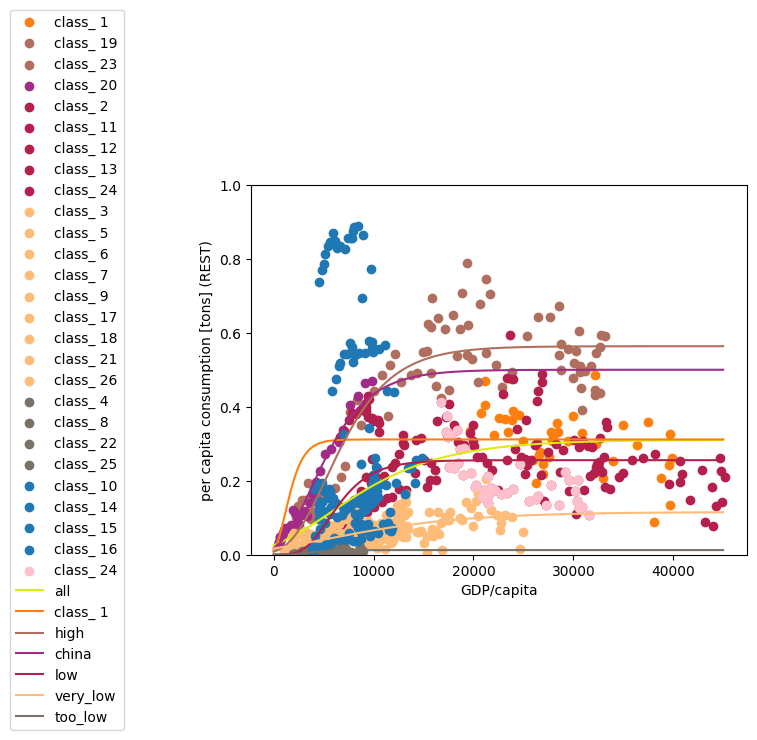

In [ ]:
# Grouping of regions for fitting

color_rest = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_china = "#a02c87"
color_class_1 = '#ff7f0e'
color_high = "#af6e5e"
color_class_20 = "#D33778"
color_class_23 = '#2ca02c'
color_very_low = '#ffbb78'
color_too_low = "#7a7167"

color_dict_fits = {
    'rest': color_rest,
    'very_low': color_very_low,
    'too_low': color_too_low,
    'class_ 1': color_class_1,
    'high': color_high,
    'low': color_low,
    'high': color_high,
    'china': color_china,
    'all': "#dceb0c",  # Color for all region
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
for region in class_1:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_class_1)

for region in high:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_high)

for region in china:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_china)

for region in low:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_low)
    
for region in very_low:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_very_low)

for region in too_low:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_too_low)

for region in rest:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_rest)

for region in ["class_ 24"]:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = "pink")

    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylim(0, 1)
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


In [24]:

steel.smooth_out_interpolation_all(10, 2012)

In [25]:
steel.region_model_match.get("class_ 20").coefs

array([0.5       , 3.37433874, 3.16539049])

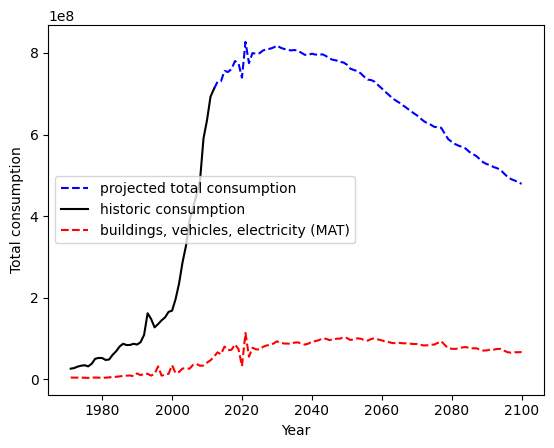

In [26]:
from imagematerials.rest_of.visualization import plot_overview_figure_total_consumption_region
    
plot_overview_figure_total_consumption_region(steel, ["class_ 20"])

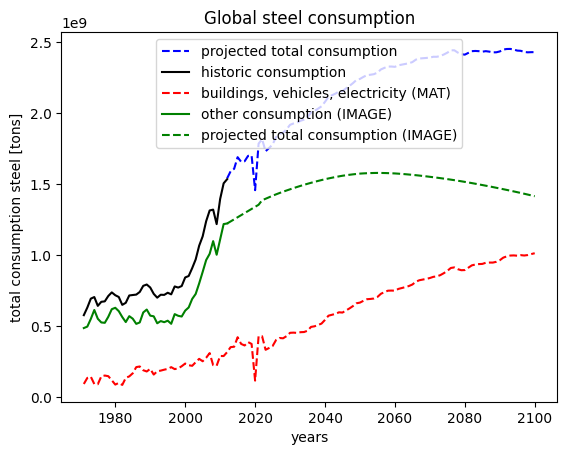

In [27]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(steel.projection_per_region_total.sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(steel.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(steel.projection_per_region_total.loc[2012: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [28]:
steel.adjust_alpha_and_project(all_regions_list_class[:-1], 
                               start_year_adjust=2050, 
                               end_year_adjust=2100, 
                               min_alpha=None)

<Axes: >

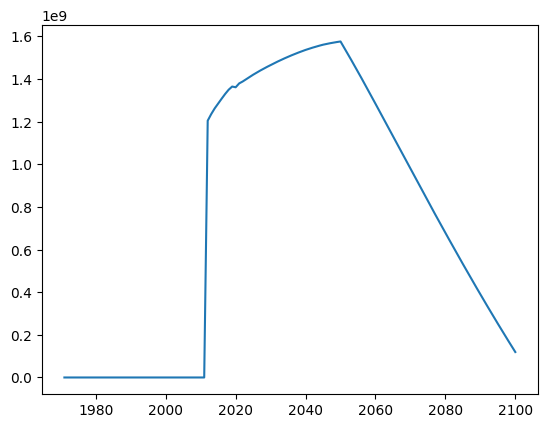

In [29]:
steel.projection_per_region_adapted_alpha.sum(axis = 1).plot()